# NB0: Data Preparation -- QC & Phenotype Classification

**FunPan Aspergillus Pangenome Project**

This notebook covers Methods 2.1--2.3 from the manuscript:
1. Load genome metadata and apply quality-control filters (BUSCO, contigs, N50)
2. ANI-based species verification to remove misidentified genomes
3. Two-tier phenotype classification (Provenance + Phenotype) with NCBI BioProject enrichment
4. Generate per-species phenotype files for downstream pan-GWAS

All outputs are saved to `NB0_Results/`.

---
## Section 1: Configuration

In [1]:
import sys, os, json, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
import seaborn as sns

# Add Analysis directory to path for funpan modules
sys.path.insert(0, '/datadrive/Analysis')

from funpan_utils import *
import funpan_classify as classify

# -- Project-level constants --
GENUS = 'Aspergillus'

SPECIES_ROOT_MAP = {
    sp: f'/datadrive/Species/Aspergillus/{sp}' for sp in SPECIES_LIST
}

# Output directory -- all results go here
RESULTS_BASE = '/datadrive/Analysis/NB0_Results'
os.makedirs(RESULTS_BASE, exist_ok=True)

# Paths to pre-existing enrichment artefacts (to avoid re-running NCBI API)
ENRICHED_CACHE = os.path.join(RESULTS_BASE, 'qc_passed_metadata_enriched.csv')
GEOCODE_CACHE_PATH = os.path.join(RESULTS_BASE, 'geocode_cache.json')
MANUAL_LATLON_PATH = os.path.join(RESULTS_BASE, 'manual_latlon_additions.txt')

# ANI results loaded from Species/ pipeline output

print('Configuration complete.')
print(f'Species: {SPECIES_LIST}')
print(f'Results will be saved to: {RESULTS_BASE}')

Configuration complete.
Species: ['fumigatus', 'flavus', 'niger', 'oryzae']
Results will be saved to: /datadrive/Analysis/NB0_Results


---
## Section 2: Load Metadata & QC

Load genome metadata from NCBI downloads, apply quality-control filters, and verify species identity via ANI.


In [2]:
# Load metadata and apply QC filter flags (funpan_utils.load_and_prepare_metadata)
df_all, filtered_accs, proteome_accs, references = load_and_prepare_metadata()

Loading metadata for all downloaded genomes...
Total genomes downloaded: 929
  fumigatus: 89 passed filtering
  flavus: 71 passed filtering
  niger: 19 passed filtering
  oryzae: 33 passed filtering

Proteomes available (filtered_protein):
  fumigatus: 30 proteomes
  flavus: 4 proteomes
  niger: 4 proteomes
  oryzae: 3 proteomes

Filtering summary: 212 passed, 717 filtered out
Identifying reference genomes (parsnp) and proteomes (funannotate)...
  fumigatus: Ref Genome = GCF_000002655.1 (RefSeq)
  fumigatus: Ref Proteome = GCF_000002655.1 (RefSeq) [SAME]
  flavus: Ref Genome = GCF_014117465.1 (RefSeq)
  flavus: Ref Proteome = GCF_014117465.1 (RefSeq) [SAME]
  niger: Ref Genome = GCF_000002855.4 (RefSeq)
  niger: Ref Proteome = GCF_000002855.4 (RefSeq) [SAME]
  oryzae: Ref Genome = GCF_000184455.2 (RefSeq)
  oryzae: Ref Proteome = GCF_000184455.2 (RefSeq) [SAME]

Reference summary:
  Ref genomes: 4
  Ref proteomes: 4


In [3]:
# ANI-based species exclusions (funpan_utils.apply_ani_exclusions)
ANI_EXCLUDED = {
    'flavus': {'GCA_023653635.1'},  # A. parasiticus (ANI=94.01% to A. flavus ref)
}
all_passed_accs = apply_ani_exclusions(df_all, filtered_accs, ANI_EXCLUDED)

  ANI exclusion: removed 1 from flavus
  After ANI exclusion: 211 passed
  fumigatus: 89 passed QC
  flavus: 70 passed QC
  niger: 19 passed QC
  oryzae: 33 passed QC

Total QC-passed assemblies: 211


In [4]:
# References already identified in load_and_prepare_metadata()
print('References per species:')
for sp, ref in references.items():
    print(f'  {sp}: genome={ref.get("ref_genome")}, proteome={ref.get("ref_proteome")}')

References per species:
  fumigatus: genome=GCF_000002655.1, proteome=GCF_000002655.1
  flavus: genome=GCF_014117465.1, proteome=GCF_014117465.1
  niger: genome=GCF_000002855.4, proteome=GCF_000002855.4
  oryzae: genome=GCF_000184455.2, proteome=GCF_000184455.2


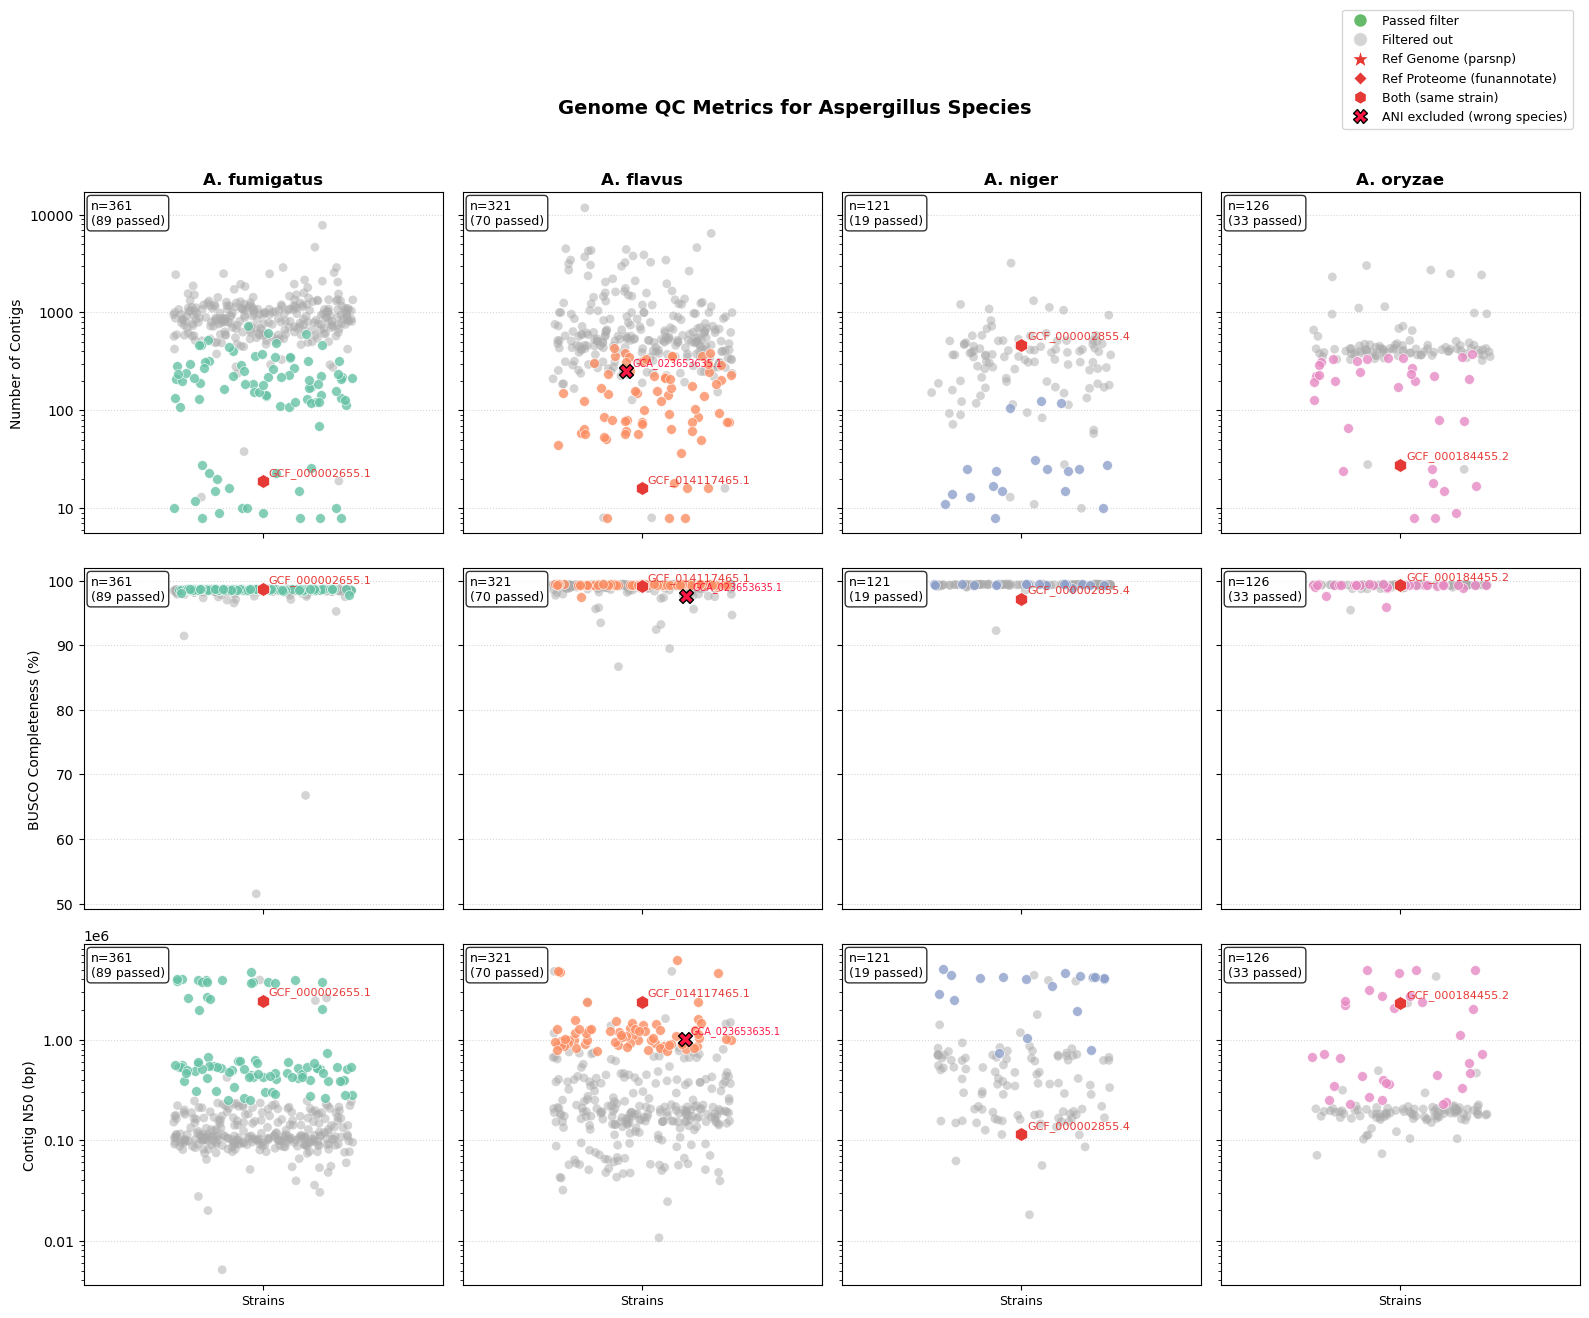

Saved QC metrics plot to /datadrive/Analysis/NB0_Results/qc_metrics.png


In [5]:
# =============================================================================
# Plot QC metrics for all species
# =============================================================================
plot_qc_metrics_per_species(df_all, SPECIES_LIST, references, ani_excluded=ANI_EXCLUDED)
plt.savefig(os.path.join(RESULTS_BASE, 'qc_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved QC metrics plot to {RESULTS_BASE}/qc_metrics.png')

ANI SPECIES VERIFICATION
  fumigatus: 89 genomes, ANI range: 99.19 - 100.00%, 0 below 95%
  flavus: 71 genomes, ANI range: 94.08 - 100.00%, 1 below 95%
  niger: 19 genomes, ANI range: 97.50 - 100.00%, 0 below 95%
  oryzae: 33 genomes, ANI range: 99.21 - 100.00%, 0 below 95%

Threshold: 95% ANI -- samples below are likely different species


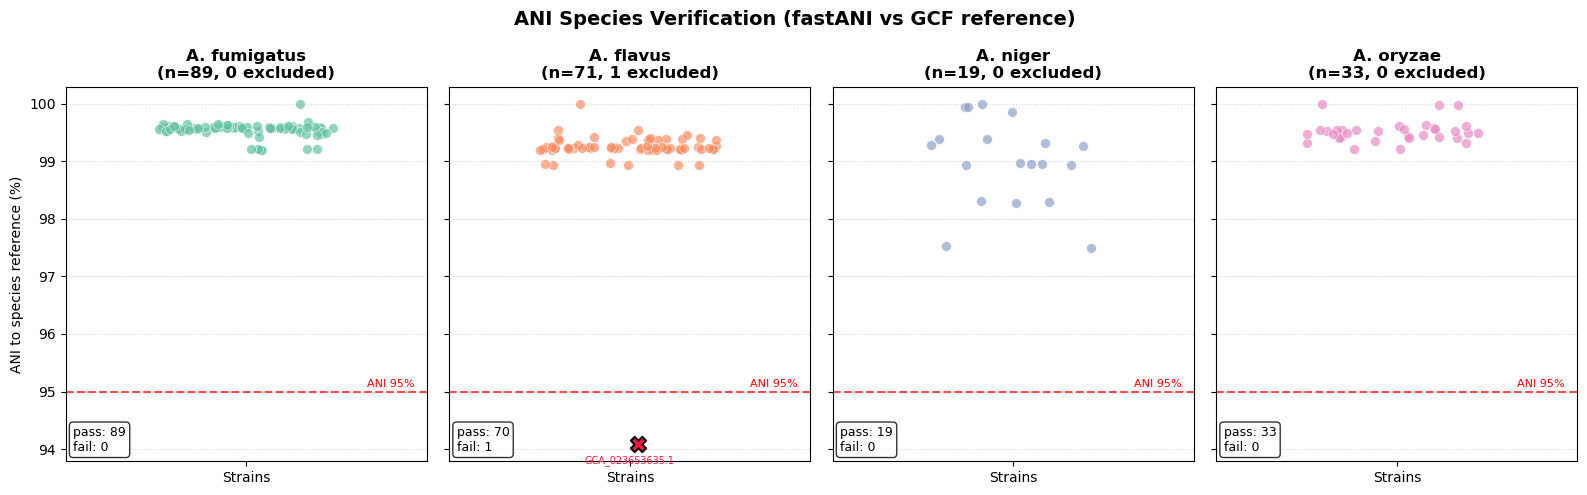

In [6]:
# ANI species verification plot (funpan_utils.load_ani_results + plot_ani_verification)
print('=' * 80)
print('ANI SPECIES VERIFICATION')
print('=' * 80)
ani_results_all = load_ani_results(SPECIES_LIST, RESULTS_BASE)
plot_ani_verification(ani_results_all, SPECIES_LIST, RESULTS_BASE)

---
### Section 2b: *Section Nigri* identity check

A few genomes deposited as *A. niger* fall **below the 95% ANI** species threshold
against the *A. niger* reference (see the ANI verification plot above). Within
*Aspergillus* section *Nigri*, the sister species *A. tubingensis* and
*A. welwitschiae* are routinely mis-deposited as *A. niger*. The cell below
downloads both references from NCBI and re-tests each low-ANI *A. niger* genome
against them, flagging any that are actually a different section *Nigri* species
(ANI &ge; 95%).

Outputs: per-comparison fastANI tables in `NB0_Results/nigri_check/` and a tidy
summary in `NB0_Results/niger_section_nigri_reassignment.csv`.

> Requires `fastANI`, `wget`, and internet access (first run downloads the two references). Ported from the standalone `run_ani_check_all_species.py`.


In [ ]:
# =============================================================================
# Section Nigri check: are the low-ANI "A. niger" genomes actually
# A. tubingensis or A. welwitschiae? (download refs + re-test with fastANI)
# =============================================================================
import subprocess, zipfile
from pathlib import Path

NIGER_ROOT = Path(SPECIES_ROOT_MAP['niger'])
NIGRI_REFS = {
    'welwitschiae': 'GCF_003344945.1',  # CBS 139.54b (Aspwel1)
    'tubingensis':  'GCA_001890745.1',  # CBS 134.48  (Asptu1)
}
ANI_THRESHOLD = 95.0
_acc_re = re.compile(r'(GC[AF]_\d+\.\d+)')

def _find_niger_reference():
    for sub in ('filtered_genome', 'genome', 'busco_output'):
        d = NIGER_ROOT / sub
        if d.exists():
            gcfs = [g for g in sorted(d.glob('GCF_*_genomic.fna')) if 'renamed' not in str(g)]
            if gcfs:
                return gcfs[0]
    return None

def _niger_genomes(filtered=True):
    d = NIGER_ROOT / ('filtered_genome' if filtered else 'genome')
    if not d.exists():
        return []
    return [f for f in sorted(d.glob('*_genomic.fna'))
            if 'renamed' not in str(f) and '.map' not in str(f)]

def _run_fastani(query_paths, ref_path, out_path, threads=8):
    out_path = Path(out_path)
    ql = out_path.with_suffix('.querylist.txt')
    ql.write_text('\n'.join(str(p) for p in query_paths) + '\n')
    try:
        subprocess.run(['fastANI', '--ql', str(ql), '--ref', str(ref_path),
                        '-o', str(out_path), '-t', str(threads)],
                       capture_output=True, text=True, timeout=3600)
    except FileNotFoundError:
        print('  ERROR: fastANI not found in PATH (activate the funpan env).')
        return []
    except subprocess.TimeoutExpired:
        print('  ERROR: fastANI timed out.')
        return []
    rows = []
    if out_path.exists():
        for line in open(out_path):
            p = line.strip().split('\t')
            if len(p) >= 3:
                m = _acc_re.search(p[0])
                rows.append({'query': m.group(1) if m else p[0], 'ani': float(p[2])})
    return rows

def _download_genome(accession, out_dir):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    existing = list(out_dir.glob(f'{accession}*_genomic.fna'))
    if existing:
        return existing[0]
    zip_path = out_dir / f'{accession}.zip'
    url = ('https://api.ncbi.nlm.nih.gov/datasets/v2/genome/accession/'
           f'{accession}/download?include_annotation_type=GENOME_FASTA')
    try:
        r = subprocess.run(['wget', '-q', url, '-O', str(zip_path)],
                           capture_output=True, text=True, timeout=300)
        if r.returncode != 0:
            print(f'    ERROR: download failed for {accession}'); return None
    except FileNotFoundError:
        print('    ERROR: wget not found'); return None
    try:
        with zipfile.ZipFile(zip_path) as z:
            for member in z.namelist():
                if member.endswith('.fna') and 'genomic' in member:
                    out_genome = out_dir / f'{accession}_genomic.fna'
                    out_genome.write_bytes(z.read(member))
                    zip_path.unlink(missing_ok=True)
                    return out_genome
    except Exception as e:
        print(f'    ERROR extracting {accession}: {e}')
    return None

print('=' * 80)
print('SECTION NIGRI CHECK -- low-ANI A. niger genomes')
print('=' * 80)

niger_ref = _find_niger_reference()
nigri_summary = []
if niger_ref is None:
    print('No A. niger GCF reference found -- skipping section Nigri check.')
else:
    genomes = _niger_genomes(filtered=True)
    print(f'A. niger reference: {niger_ref.name}')
    print(f'Filtered genomes:   {len(genomes)}')
    out_dir = Path(RESULTS_BASE) / 'nigri_check'; out_dir.mkdir(parents=True, exist_ok=True)

    ref_rows = _run_fastani(genomes, niger_ref, out_dir / 'niger_vs_niger_ref.tsv')
    low = sorted([r for r in ref_rows if r['ani'] < ANI_THRESHOLD], key=lambda x: x['ani'])
    print(f'Below {ANI_THRESHOLD}% ANI to A. niger: {len(low)}')
    for r in low:
        print(f"  {r['query']}  ANI={r['ani']:.2f}%")

    if low:
        low_accs = {r['query'].split('.')[0] for r in low}
        low_paths = [g for g in genomes if any(a in g.name for a in low_accs)]
        ref_root = NIGER_ROOT / 'nigri_references'
        for sp, acc in NIGRI_REFS.items():
            print(f'\n--- vs A. {sp} ({acc}) ---')
            ref_genome = _download_genome(acc, ref_root)
            if ref_genome is None:
                print('    Could not obtain reference -- skipping.'); continue
            rows = _run_fastani(low_paths, ref_genome, out_dir / f'niger_low_ani_vs_{sp}.tsv')
            for r in sorted(rows, key=lambda x: -x['ani']):
                verdict = 'MATCH' if r['ani'] >= ANI_THRESHOLD else '-'
                print(f"  {r['query']}  ANI={r['ani']:.2f}%  {verdict}")
                nigri_summary.append({'genome': r['query'], 'vs_species': sp,
                                      'ani': r['ani'], 'is_match': r['ani'] >= ANI_THRESHOLD})
    else:
        print('All filtered A. niger genomes pass the species threshold -- nothing to reassign.')

if nigri_summary:
    nigri_df = pd.DataFrame(nigri_summary)
    nigri_csv = os.path.join(RESULTS_BASE, 'niger_section_nigri_reassignment.csv')
    nigri_df.to_csv(nigri_csv, index=False)
    print(f'\nSaved: {nigri_csv}')
    display(nigri_df)


In [7]:
# QC summary tables (funpan_utils.build_qc_summary_tables)
summary_df, qc_stats_df = build_qc_summary_tables(df_all, SPECIES_LIST, references)
print('Genome QC Filtering & Reference Summary:')
print('=' * 120)
display(summary_df)
print('\nQC Metrics Summary (passed genomes only):')
display(qc_stats_df)

Genome QC Filtering & Reference Summary:


,Species,Downloaded,Passed,Filtered,Pass %,Ref Genome,G Type,Ref Proteome,P Type,Same?
0,A. fumigatus,361,89,272,24.7,GCF_000002655.1,RefSeq,GCF_000002655.1,RefSeq,Yes
1,A. flavus,321,70,251,21.8,GCF_014117465.1,RefSeq,GCF_014117465.1,RefSeq,Yes
2,A. niger,121,19,102,15.7,GCF_000002855.4,RefSeq,GCF_000002855.4,RefSeq,Yes
3,A. oryzae,126,33,93,26.2,GCF_000184455.2,RefSeq,GCF_000184455.2,RefSeq,Yes



QC Metrics Summary (passed genomes only):


,Species,Median Contigs,Median BUSCO,Median N50,Min BUSCO,Max Contigs
0,A. fumigatus,186,98.6%,0.52 Mb,97.8%,730
1,A. flavus,126,99.4%,1.04 Mb,97.5%,435
2,A. niger,24,99.4%,4.07 Mb,97.2%,469
3,A. oryzae,200,99.3%,0.67 Mb,95.9%,375


In [8]:
# --- Interpretation: QC Summary ---
n_total = len(df_all)
n_passed = sum(len(v) for v in filtered_accs.values())
n_excluded = sum(len(v) for v in ANI_EXCLUDED.values()) if 'ANI_EXCLUDED' in dir() else 0
print(f'QC Summary')
print(f'==========')
print(f'{n_total} genomes downloaded across {len(SPECIES_LIST)} Aspergillus species.')
print(f'{n_passed} passed quality filters (BUSCO completeness, contig count, N50).')
if n_excluded > 0:
    print(f'{n_excluded} excluded by ANI species verification (fastANI < 95%).')
for sp in SPECIES_LIST:
    n_sp = len(filtered_accs.get(sp, []))
    n_ex = len(ANI_EXCLUDED.get(sp, set())) if 'ANI_EXCLUDED' in dir() else 0
    print(f'  A. {sp}: {n_sp} passed QC' + (f', {n_ex} ANI-excluded' if n_ex else ''))


QC Summary
929 genomes downloaded across 4 Aspergillus species.
211 passed quality filters (BUSCO completeness, contig count, N50).
1 excluded by ANI species verification (fastANI < 95%).
  A. fumigatus: 89 passed QC
  A. flavus: 70 passed QC, 1 ANI-excluded
  A. niger: 19 passed QC
  A. oryzae: 33 passed QC


---
## Section 3: Phenotype Classification

Two-tier classification assigns each genome a **Provenance** label (where the strain was
physically isolated) and a **Phenotype** label (biological association for pan-GWAS).
NCBI BioProject and WGS title enrichment provides additional textual evidence for the
weighted rules engine.

In [9]:
# Load or build enriched metadata (funpan_utils.load_or_build_enriched_metadata)
df_meta = load_or_build_enriched_metadata(all_passed_accs, ENRICHED_CACHE, RESULTS_BASE)

Loading pre-enriched metadata from /datadrive/Analysis/NB0_Results/qc_passed_metadata_enriched.csv
  Loaded 211 assemblies

Saved enriched metadata to /datadrive/Analysis/NB0_Results/qc_passed_metadata_enriched.csv

Species distribution:
Species
A. fumigatus    89
A. flavus       70
A. oryzae       33
A. niger        19
Name: count, dtype: int64

BioProject Description: 211/211 non-empty

WGS Reference Title: 197/211 non-empty


In [10]:
# Run two-tier classification (funpan_classify.classify_dataframe)
print('Running TWO-TIER classification on QC-passed assemblies...')
df_classified = classify.classify_dataframe(df_meta, debug=False)
print('Classification complete!')
classify.summarize_classification(df_classified)

Running TWO-TIER classification on QC-passed assemblies...
Classification complete!

TWO-TIER ISOLATION SOURCE CLASSIFICATION SUMMARY

Total samples: 211

----------------------------------------------------------------------
A) PROVENANCE (where physically isolated from)
----------------------------------------------------------------------
  Clinical: 122 (57.8%)
  Environmental: 44 (20.9%)
  Industrial-origin: 26 (12.3%)
  Unknown: 10 (4.7%)
  Culture-derived: 9 (4.3%)

  Confidence by provenance:
  ProvenanceConfidence  high  low  medium
  Provenance                             
  Clinical               104    0      18
  Culture-derived          2    3       4
  Environmental            0   15      29
  Industrial-origin       13    0      13
  Unknown                  0   10       0

----------------------------------------------------------------------
B) PHENOTYPE (biological association - for pan-GWAS)
----------------------------------------------------------------------
  Hu

,count
Phenotype,
Human-pathogenic,81
Environmental,60
Industrial-trait,46
Plant-pathogenic,19
Unknown,4
Animal-pathogenic,1


In [11]:
# Save classified outputs (funpan_utils.save_classified_outputs)
df_analysis = save_classified_outputs(df_classified, RESULTS_BASE)

Saved FULL classified data (including Unknown) to:
  /datadrive/Analysis/NB0_Results/qc_passed_classified_all.csv

Analysis dataset (excluding 4 Unknown + 0 Lab phenotypes):
Phenotype
Human-pathogenic     81
Environmental        60
Industrial-trait     46
Plant-pathogenic     19
Animal-pathogenic     1

Saved analysis data (excluding Unknown/Lab) to:
  /datadrive/Analysis/NB0_Results/qc_passed_classified_known.csv

Saved pan-GWAS phenotype data to:
  /datadrive/Analysis/NB0_Results/phenotype_classified_for_gwas.csv

Available dataframes:
  df_classified: 211 assemblies (ALL, including Unknown/Lab)
  df_analysis:   207 assemblies (for pan-GWAS, no Unknown/Lab)


In [12]:
# --- Interpretation: Classification Summary ---
print('Classification Summary')
print('=====================')
print(f'{len(df_classified)} genomes classified with two-tier system.')
print(f'{len(df_analysis)} genomes with known phenotype (excl. Unknown/Lab) available for pan-GWAS.')
print()
print('Phenotype distribution:')
for pheno, count in df_analysis['Phenotype'].value_counts().items():
    pct = 100 * count / len(df_analysis)
    print(f'  {pheno}: {count} ({pct:.1f}%)')
print()
print('Provenance distribution:')
for prov, count in df_classified['Provenance'].value_counts().items():
    pct = 100 * count / len(df_classified)
    print(f'  {prov}: {count} ({pct:.1f}%)')


Classification Summary
211 genomes classified with two-tier system.
207 genomes with known phenotype (excl. Unknown/Lab) available for pan-GWAS.

Phenotype distribution:
  Human-pathogenic: 81 (39.1%)
  Environmental: 60 (29.0%)
  Industrial-trait: 46 (22.2%)
  Plant-pathogenic: 19 (9.2%)
  Animal-pathogenic: 1 (0.5%)

Provenance distribution:
  Clinical: 122 (57.8%)
  Environmental: 44 (20.9%)
  Industrial-origin: 26 (12.3%)
  Unknown: 10 (4.7%)
  Culture-derived: 9 (4.3%)


---
## Section 4: Visualization

Saved to /datadrive/Analysis/NB0_Results/phenotype_distribution_pie.png  (+ .pdf)
Saved to /datadrive/Analysis/NB0_Results/phenotype_distribution_bar.png  (+ .pdf)


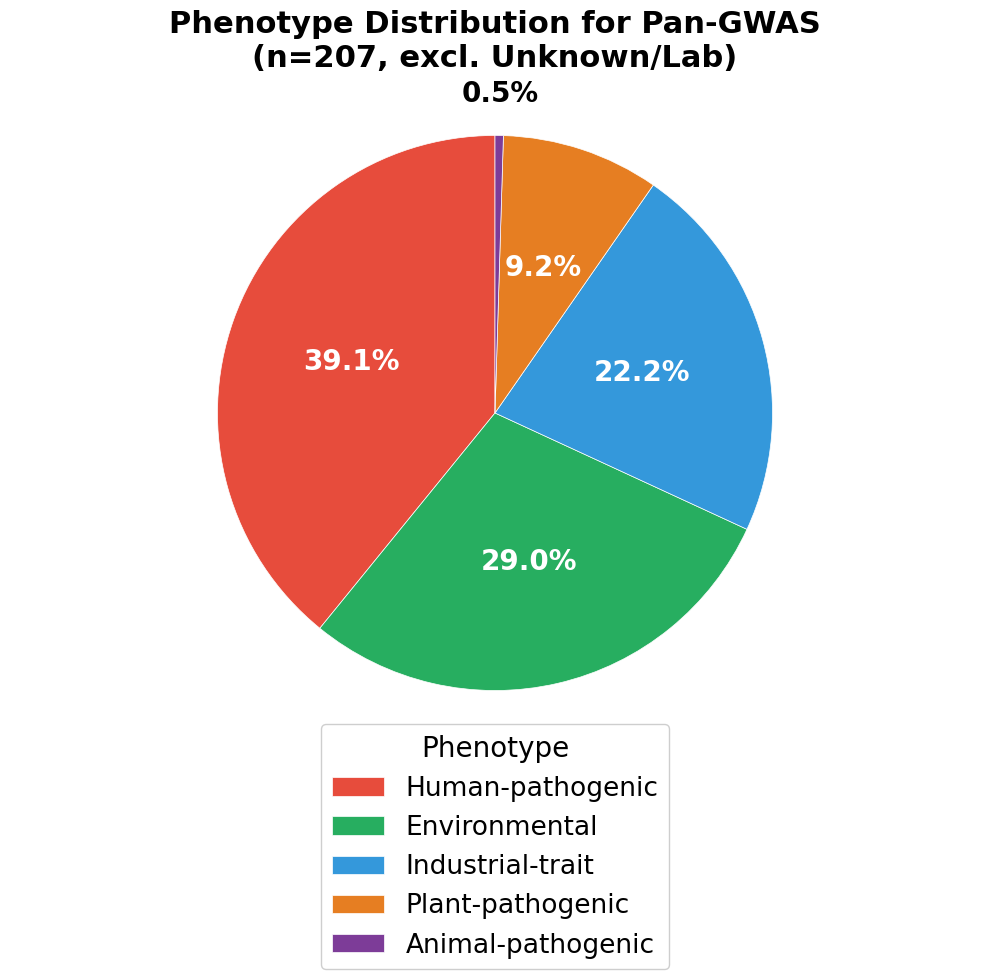

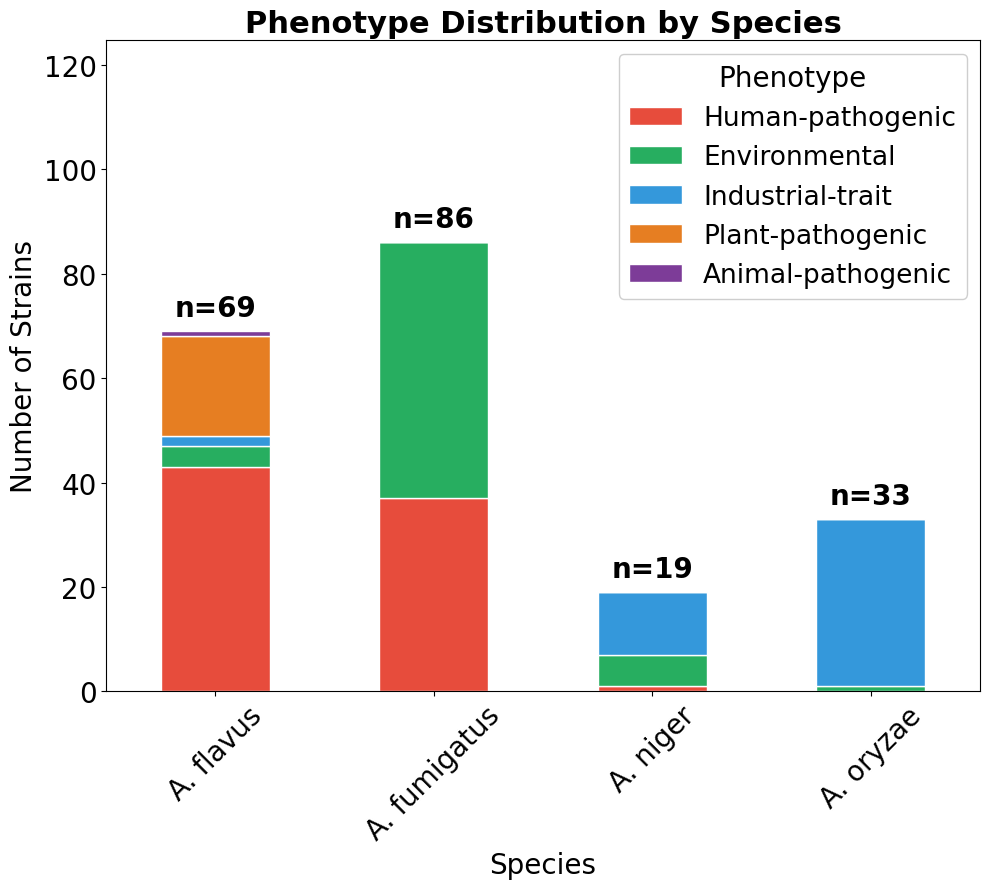

In [32]:
# Phenotype distribution — saved as TWO SEPARATE figures (pie + bar)
# --- Tweakable parameters — adjust here, no need to edit the source module ---
FIGURE_FONTSIZE = 20         # base font size (title +2, legend labels -1)
FIGURE_DPI      = 800        # PNG/PDF resolution
PIE_FIGSIZE     = (10, 11)   # pie figure size (width, height) in inches
BAR_FIGSIZE     = (10, 9)    # bar figure size (width, height) in inches
PIE_LEGEND_NCOL = 1          # 1 = tall single column, 2-3 = wider/shorter
BAR_YLIM_FACTOR = 1.45       # bar y headroom; raise if legend overlaps a bar

import importlib, funpan_utils
importlib.reload(funpan_utils)
from funpan_utils import plot_phenotype_distribution

fig_pie, fig_bar = plot_phenotype_distribution(
    df_analysis, RESULTS_BASE,
    fontsize=FIGURE_FONTSIZE,
    dpi=FIGURE_DPI,
    pie_figsize=PIE_FIGSIZE,
    bar_figsize=BAR_FIGSIZE,
    pie_legend_ncol=PIE_LEGEND_NCOL,
    bar_ylim_factor=BAR_YLIM_FACTOR,
)


Extracting coordinates for strain locations...
Loaded manual coordinates: 2 by location, 5 by strain

Coordinates found for 187/207 samples (90.3%)
  From Lat/Lon column: 86
  From Manual additions: 10
  From Geo Location (geocoded): 0
  From Geo Location (cached): 91

Map saved to: /datadrive/Analysis/NB0_Results/strain_world_map.png


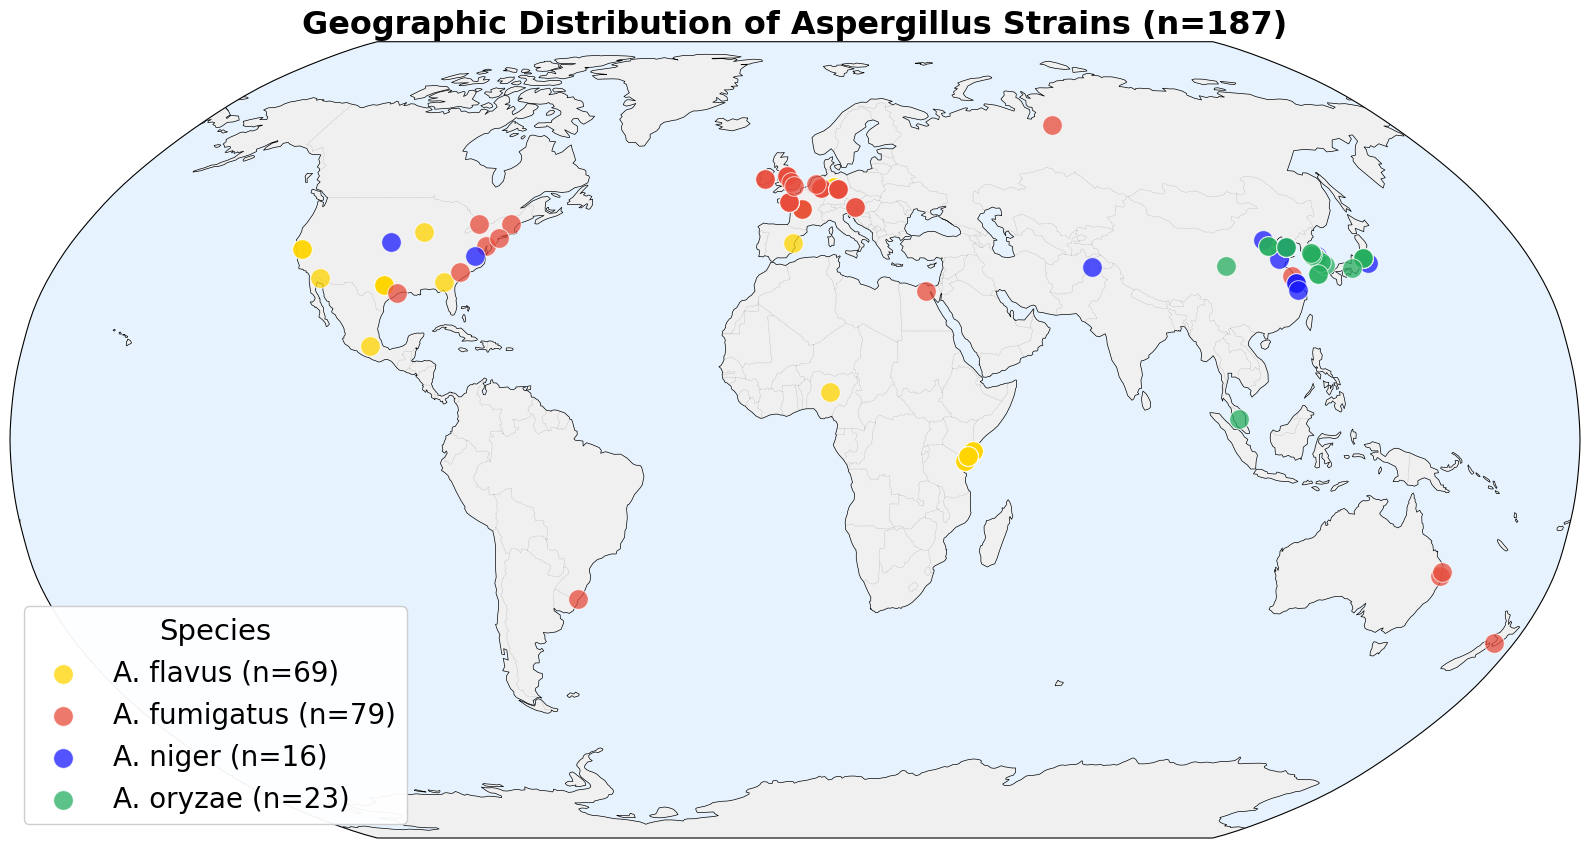

In [ ]:
# Strain world map (funpan_classify.build_strain_coordinates + plot_strain_world_map_from_coords)
# --- Tweakable parameters — adjust here, no need to edit the source module ---
FIGURE_FONTSIZE = 20       # base font size (title +3, legend title +1)
FIGURE_DPI      = 800       # PNG resolution
FIGURE_SIZE     = (16, 12)  # (width, height) in inches
MARKER_SIZE     = 200       # scatter marker area (points^2); try 150-300 for poster
import importlib
importlib.reload(classify)

df_coords = classify.build_strain_coordinates(df_analysis)
classify.plot_strain_world_map_from_coords(
    df_coords, RESULTS_BASE,
    fontsize=FIGURE_FONTSIZE,
    dpi=FIGURE_DPI,
    figsize=FIGURE_SIZE,
    marker_size=MARKER_SIZE,
)


---
## Section 5: Per-Species Phenotype Files

For each species, create:
- `phenotype_data.tsv` -- master sample sheet with phenotype labels
- `phenotypes/pheno_*.tsv` -- binary contrast files for pan-GWAS (strict/broad/lenient confidence modes)

In [15]:
# Generate per-species phenotype files (funpan_classify.generate_per_species_phenotype_files)
classify.generate_per_species_phenotype_files(
    df_classified, SPECIES_LIST, SPECIES_DISPLAY, RESULTS_BASE
)


A. fumigatus (89 samples)
  Saved master sample sheet: /datadrive/Analysis/NB0_Results/fumigatus/fumigatus_samples.tsv
  Saved phenotype data: /datadrive/Analysis/NB0_Results/fumigatus/phenotype_data.tsv

  Label distribution:
label_short
Environmental    49
Human            37
Unknown           3

  Creating phenotype contrast files...
    strict = high confidence only
    broad  = high + medium confidence
    lenient = all confidence levels
  pheno_human_vs_env_strict.tsv: Human=28, Environmental=1
  pheno_human_vs_env_broad.tsv: Human=35, Environmental=2
  pheno_human_vs_env_lenient.tsv: Human=37, Environmental=49
  Created 3 phenotype files in /datadrive/Analysis/NB0_Results/fumigatus/phenotypes

A. flavus (70 samples)
  Saved master sample sheet: /datadrive/Analysis/NB0_Results/flavus/flavus_samples.tsv
  Saved phenotype data: /datadrive/Analysis/NB0_Results/flavus/phenotype_data.tsv

  Label distribution:
label_short
Human            43
Plant            19
Environmental     4
In

---
## Section 6: Summary

Final genome counts per species per phenotype category.

In [16]:
# Final summary cross-tabulations (funpan_utils.print_nb0_summary)
crosstab, crosstab_prov = print_nb0_summary(df_classified, df_analysis, SPECIES_LIST, RESULTS_BASE)
display(crosstab)
display(crosstab_prov)

Genome counts per species per phenotype:

Genome counts per species per provenance:

NB0 Data Preparation complete.
All outputs saved to: /datadrive/Analysis/NB0_Results
  - qc_passed_metadata_enriched.csv
  - qc_passed_classified_all.csv  (211 genomes)
  - qc_passed_classified_known.csv (207 genomes)
  - phenotype_classified_for_gwas.csv
  - phenotype_distribution.png
  - strain_world_map.png
  - fumigatus/phenotype_data.tsv
  - fumigatus/phenotypes/pheno_*.tsv
  - flavus/phenotype_data.tsv
  - flavus/phenotypes/pheno_*.tsv
  - niger/phenotype_data.tsv
  - niger/phenotypes/pheno_*.tsv
  - oryzae/phenotype_data.tsv
  - oryzae/phenotypes/pheno_*.tsv


Phenotype,Animal-pathogenic,Environmental,Human-pathogenic,Industrial-trait,Plant-pathogenic,Unknown,All
Species,,,,,,,
A. flavus,1,4,43,2,19,1,70
A. fumigatus,0,49,37,0,0,3,89
A. niger,0,6,1,12,0,0,19
A. oryzae,0,1,0,32,0,0,33
All,1,60,81,46,19,4,211


Provenance,Clinical,Culture-derived,Environmental,Industrial-origin,Unknown,All
Species,,,,,,
A. flavus,46,1,18,3,2,70
A. fumigatus,74,0,10,0,5,89
A. niger,2,6,6,4,1,19
A. oryzae,0,2,10,19,2,33
All,122,9,44,26,10,211
